In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_lstm_with_mask_action as d3qn_per_agent
import configurations.config_p2_sub6 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p2_sub6' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p2_sub6.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_lstm_with_mask_action import D3QN_PER
from configurations.config_p2_sub6 import config

In [5]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 64, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0007, 'MAX_TRAIN_EPISODES': 250, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 100, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x000002218115BF60>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x000002218115BEC0>, 'max_steps': 1000, 'epochs': 20, 'epsilon': 0.58, 'eps_decay_strategy': [('exponential', {'s': 0, 'e': 249, 'ival': 1.0, 'fval': 0.005})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.002, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [512, 256, 128], 'lstm_hDim': 128, 'model_path': '../model_weights_phase2_sub6', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 15, 'mask_lambda': 0.05, 'mask_threshold': -20.0, 'minSamples': 2, 'sampleAction': False}


In [6]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=2
)
d3qnPerwithLSTMAgent = D3QN_PER(env, config)

In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerwithLSTMAgent.runD3QN_PER()

Episode 0: TR -8175.0 | ER -73903.8 | TT 9.436917781829834 | WC 51.301291942596436 | TS 1000
Episode 1: TR -43171.0 | ER -75216.4 | TT 59.27634239196777 | WC 99.34482502937317 | TS 1000
Episode 2: TR -11379.0 | ER -120205.6 | TT 114.86436009407043 | WC 154.8142580986023 | TS 1000
Episode 3: TR -26384.0 | ER -103617.4 | TT 169.34373235702515 | WC 244.22072744369507 | TS 1000
Episode 4: TR -48174.0 | ER -115865.4 | TT 270.5186674594879 | WC 349.7028822898865 | TS 1000
Episode 5: TR -20870.0 | ER -44185.0 | TT 376.73238611221313 | WC 455.3040146827698 | TS 1000
Episode 6: TR -12783.0 | ER -160684.6 | TT 476.9918360710144 | WC 525.4320919513702 | TS 1000
Episode 7: TR -14774.0 | ER -109905.8 | TT 553.333934545517 | WC 627.6593189239502 | TS 1000
Episode 8: TR -58967.0 | ER -89396.0 | TT 653.9069511890411 | WC 729.9512774944305 | TS 1000
Episode 9: TR -37769.0 | ER -77139.8 | TT 754.5996539592743 | WC 817.0205647945404 | TS 1000
Episode 10: TR -11769.0 | ER -980.6 | TT 843.1258773803711 | W

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
import numpy as np
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -12500.0


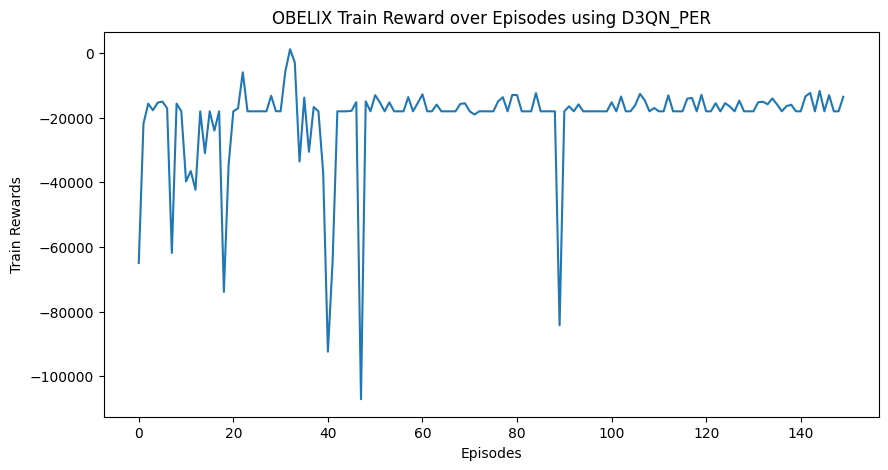

In [ ]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

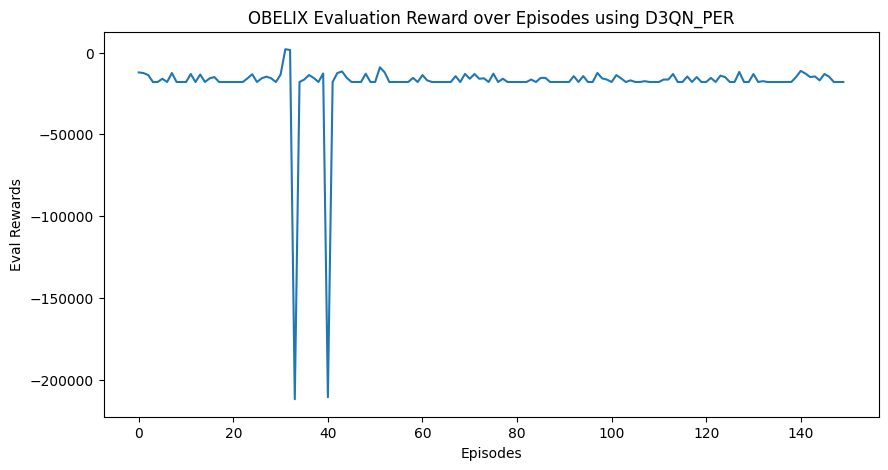

In [ ]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

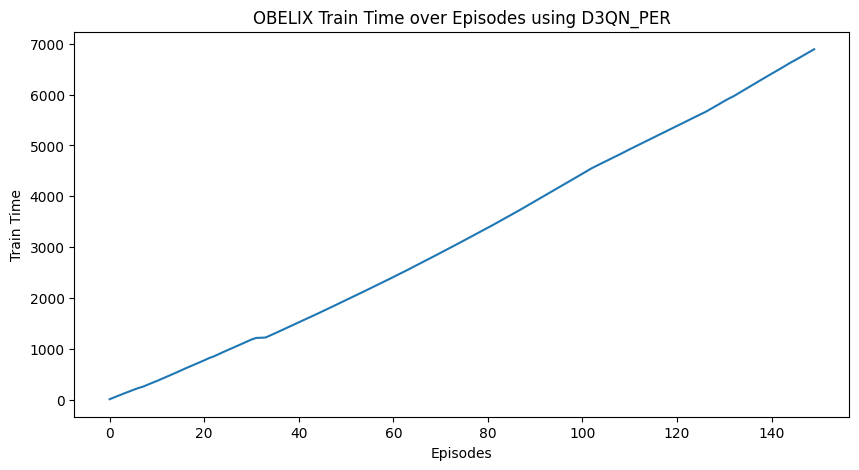

In [ ]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

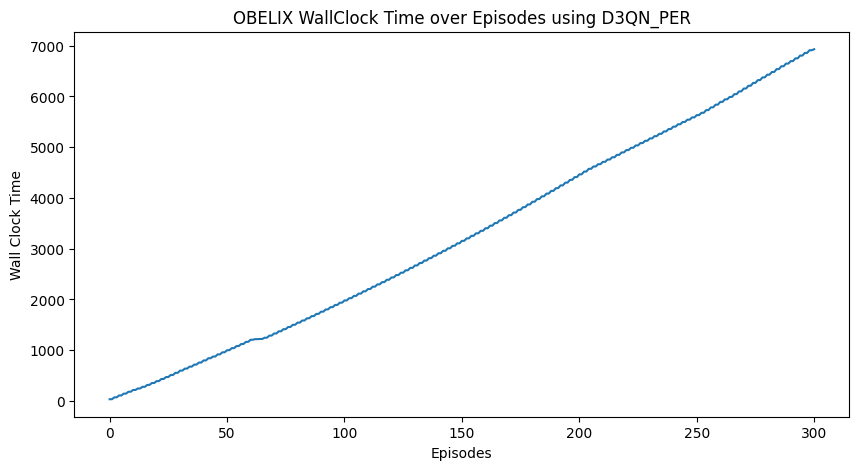

In [ ]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

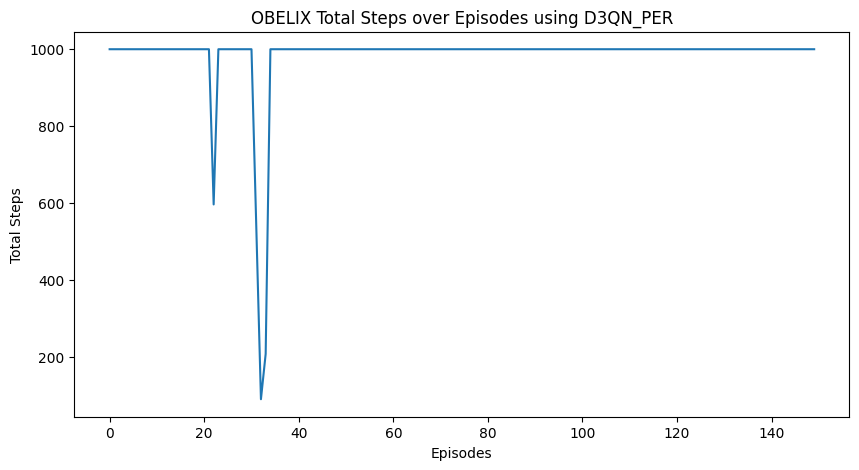

: 

In [ ]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)